In [2]:
import pandas as pd
from pathlib import Path
import sys
import plotly.express as px
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

ROOT = Path("../")
sys.path.append(str(ROOT / "src"))

import puppet

/Users/gustavidunsloth/Documents/Data Science/YouTube Algorithm Audit/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-10-17 15:13:21 [INFO] Database: Building database...


Running on: mps with 8 threads


In [3]:
path = "../data/puppets/test-17-10"
puppets = [pd.read_pickle(p) for p in Path(path).glob("*.pkl")]
df = pd.concat(puppets,ignore_index=True)
df.head()

,puppet_id,puppet_state,puppet_slant,puppet_cond,depth,video_id,video_slant,recs_id,recs_slant,errors,source,watch_time
0,p-5r6HPyFwYJbGTuhGWtKwYL,training,1.0,"(1, 0)",1,bF3JNZv2ASM,1.0,"[ykxeOWl-c_0, 0g4MaIzw4Hk, Fg09g1WalWA, JiLtCg...","[None, None, None, None, None, None, None, None]",[],video,35.956735
1,p-5r6HPyFwYJbGTuhGWtKwYL,training,1.0,"(1, 0)",2,ecUbrVX7_Ow,1.0,"[oQ1jbdu1NaM, qu3ixTQmpl0, Jx9Mu7iyP7k, 9C_Pdl...","[None, None, None, None, None, None, None, None]",[],video,40.023962
2,p-5r6HPyFwYJbGTuhGWtKwYL,training,1.0,"(1, 0)",3,-JLzkoK3CZw,1.0,"[zqYEsyM3jgg, bqWwV3xk9Qk, 1eC66kIDDCg, KmAF_W...","[None, None, None, None, None, None, None, None]",[],video,34.460823
3,p-5r6HPyFwYJbGTuhGWtKwYL,training,1.0,"(1, 0)",4,N6Z359U77XY,1.0,"[K4iIOn9ccNg, eH612ZiiwKQ, egc383MQz3I, 1Pl3Y-...","[None, None, None, None, None, None, None, None]",[],video,36.883684
4,p-5r6HPyFwYJbGTuhGWtKwYL,training,1.0,"(1, 0)",5,bzHrD2f3saM,1.0,"[jVu-yYtYttA, ykxeOWl-c_0, Bmvxx_YbDsM, UAT-eO...","[None, None, None, None, None, None, None, None]",[],video,32.474940


In [339]:
df["mean_rec_slant"] = df["recs_slant"].apply(
    lambda x: None if x is None or len(x) == 0 or x[0] is None else np.mean(x)
)
df["sd_rec_slant"] = df["recs_slant"].apply(
    lambda x: None if x is None or len(x) == 0 or x[0] is None else np.std(x)
)
df["first_rec_slant"] = df["recs_slant"].apply(
    lambda x: None if x is None or len(x) == 0 or x[0] is None else x[0]
)

df["rec_max"] = df["recs_slant"].apply(
    lambda x: None if x is None or len(x) == 0 or x[0] is None else max(x)
)

df["rec_min"] = df["recs_slant"].apply(
    lambda x: None if x is None or len(x) == 0 or x[0] is None else min(x)
)

cond_map = {
    (0,1): "radicalisation",
    (0,-1): "radicalisation",
    (1,-1): "inversion",
    (-1,1): "inversion",
    (1,0): "deradicalisation",
    (-1,0): "deradicalisation",
    (0,0): "static",
    (1,1): "static",
    (-1,-1): "static"
}

cond_dir = {
    (0,1): "right",
    (0,-1): "left",
    (1,-1): "left",
    (-1,1): "right",
    (1,0): "left",
    (-1,0): "right",
    (0,0): "static",
    (1,1): "static",
    (-1,-1): "static"
}

df["slant_label"] = pd.cut(
    df["puppet_slant"],
    bins=[-1.1, -0.6, -0.2, 0.2, 0.6, 1.1],
    labels=["Far left", "Left", "Center", "Right", "Far right"]
)

df["video_slant_label"] = pd.cut(
    df["video_slant"],
    bins=[-1.1, -0.6, -0.2, 0.2, 0.6, 1.1],
    labels=["Far left", "Left", "Center", "Right", "Far right"]
)

df["cond_group"] = df["puppet_cond"].map(cond_map)

df["cond_dir"] = df["puppet_cond"].map(cond_dir)

df["static"] = df["cond_dir"].apply(
    lambda x: True if x is "static" else False
)


def rec_mean_dist(row):
    recs = row["recs_slant"]
    puppet  = row["puppet_slant"]

    # Guard clauses for invalid data
    if recs is None or len(recs) == 0 or puppet is None:
        return np.nan

    if pd.isna(puppet) or pd.isna(recs).any():
        return np.nan

    mean = np.mean(row["recs_slant"])
    
    return abs(mean - puppet)

def rec_mean_diff(row):
    recs = row["recs_slant"]
    puppet  = row["puppet_slant"]

    # Guard clauses for invalid data
    if recs is None or len(recs) == 0 or puppet is None:
        return np.nan

    if pd.isna(puppet) or pd.isna(recs).any():
        return np.nan

    mean = np.mean(row["recs_slant"])
    
    return mean - puppet

def farthest_slant(row):
    recs = row["recs_slant"]
    vid  = row["video_slant"]

    # Guard clauses for invalid data
    if recs is None or len(recs) == 0 or vid is None:
        return np.nan

    # Return the recommendation with *largest absolute distance* from the video slant
    return max(recs, key=lambda x: abs(x - vid) if x is not None else np.nan)

df["rec_mean_dist"] = df.apply(rec_mean_dist, axis=1)

df["rec_mean_diff"] = df.apply(rec_mean_diff, axis=1)

df["farthest_slant"] = df.apply(farthest_slant, axis=1)

df[:-5]

<>:60: SyntaxWarning:

"is" with a literal. Did you mean "=="?

<>:60: SyntaxWarning:

"is" with a literal. Did you mean "=="?

/var/folders/p6/8cdyrdjx0bb9nc27_9f01gpw0000gn/T/ipykernel_7007/1716332950.py:60: SyntaxWarning:

"is" with a literal. Did you mean "=="?



,puppet_id,puppet_state,puppet_slant,puppet_cond,depth,video_id,video_slant,recs_id,recs_slant,errors,...,slant_label,cond_group,cond_dir,static,rec_mean_dist,farthest_slant,rec_mean_diff,video_slant_label,rec_max,rec_min
0,p-5r6HPyFwYJbGTuhGWtKwYL,training,1.000,"(1, 0)",1,bF3JNZv2ASM,1.000000,"[ykxeOWl-c_0, 0g4MaIzw4Hk, Fg09g1WalWA, JiLtCg...","[None, None, None, None, None, None, None, None]",[],...,Far right,deradicalisation,left,False,NaN,NaN,NaN,Far right,NaN,NaN
1,p-5r6HPyFwYJbGTuhGWtKwYL,training,1.000,"(1, 0)",2,ecUbrVX7_Ow,1.000000,"[oQ1jbdu1NaM, qu3ixTQmpl0, Jx9Mu7iyP7k, 9C_Pdl...","[None, None, None, None, None, None, None, None]",[],...,Far right,deradicalisation,left,False,NaN,NaN,NaN,Far right,NaN,NaN
2,p-5r6HPyFwYJbGTuhGWtKwYL,training,1.000,"(1, 0)",3,-JLzkoK3CZw,1.000000,"[zqYEsyM3jgg, bqWwV3xk9Qk, 1eC66kIDDCg, KmAF_W...","[None, None, None, None, None, None, None, None]",[],...,Far right,deradicalisation,left,False,NaN,NaN,NaN,Far right,NaN,NaN
3,p-5r6HPyFwYJbGTuhGWtKwYL,training,1.000,"(1, 0)",4,N6Z359U77XY,1.000000,"[K4iIOn9ccNg, eH612ZiiwKQ, egc383MQz3I, 1Pl3Y-...","[None, None, None, None, None, None, None, None]",[],...,Far right,deradicalisation,left,False,NaN,NaN,NaN,Far right,NaN,NaN
4,p-5r6HPyFwYJbGTuhGWtKwYL,training,1.000,"(1, 0)",5,bzHrD2f3saM,1.000000,"[jVu-yYtYttA, ykxeOWl-c_0, Bmvxx_YbDsM, UAT-eO...","[None, None, None, None, None, None, None, None]",[],...,Far right,deradicalisation,left,False,NaN,NaN,NaN,Far right,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30530,p-Fdz9MD2hiZSajxwNabAaKZ,drifting,-0.035,"(-1, 0)",193,EC11izPKqf0,-0.078482,"[EBG0tfc23wg, -P0dBQt-B08, eY_YrfvU7KQ, Pt7X40...","[-0.28333616256713867, -0.6913772821426392, 0....",[],...,Center,deradicalisation,right,False,0.266835,-0.824405,-0.266835,Center,0.348238,-0.824405
30531,p-Fdz9MD2hiZSajxwNabAaKZ,drifting,-0.030,"(-1, 0)",194,Pt7X40_IAS8,0.090531,"[EBG0tfc23wg, JwZrx9EBTgE, KGBpQ5p7GHM, WSna0C...","[-0.28333616256713867, -0.8488258123397827, -0...",[],...,Center,deradicalisation,right,False,0.387788,-0.906952,-0.387788,Center,0.572747,-0.906952
30532,p-Fdz9MD2hiZSajxwNabAaKZ,drifting,-0.025,"(-1, 0)",195,EBG0tfc23wg,-0.283336,"[EaHznTWyLH8, FzR_XumhJE0, KjHR8749dMI, VXBkOn...","[-0.12103778123855591, -0.13649886846542358, 0...",[],...,Center,deradicalisation,right,False,0.238737,0.566150,-0.238737,Left,0.566150,-0.824405
30533,p-Fdz9MD2hiZSajxwNabAaKZ,drifting,-0.025,"(-1, 0)",196,None,NaN,"[pIZzoKB8Ae8, usryQt2yslw, 0YOBYkh6Jv4, _qjcZK...","[None, None, None, None, None, None, None, None]",[],...,Center,deradicalisation,right,False,NaN,NaN,NaN,NaN,NaN,NaN


In [371]:
value_cols = ["puppet_slant", "video_slant", "rec_max", "rec_min", "mean_rec_slant"]

df_long = (
    df
    .melt(
        id_vars=["puppet_id", "puppet_state", "puppet_cond",
                 "depth", "cond_group", "cond_dir", "static",
                 "slant_label", "video_slant_label"],
        value_vars=value_cols,
        var_name="series",
        value_name="slant"
    )
    .dropna(subset=["slant"])
)

# ensure numeric
df_long["slant"] = pd.to_numeric(df_long["slant"], errors="coerce")
df_long = df_long.dropna(subset=["slant"])



In [368]:
df_long[:-5]

,puppet_id,puppet_state,puppet_cond,depth,cond_group,cond_dir,static,slant_label,video_slant_label,series,slant
0,p-5r6HPyFwYJbGTuhGWtKwYL,training,"(1, 0)",1,deradicalisation,left,False,Far right,Far right,Puppet slant,1.000000
1,p-5r6HPyFwYJbGTuhGWtKwYL,training,"(1, 0)",2,deradicalisation,left,False,Far right,Far right,Puppet slant,1.000000
2,p-5r6HPyFwYJbGTuhGWtKwYL,training,"(1, 0)",3,deradicalisation,left,False,Far right,Far right,Puppet slant,1.000000
3,p-5r6HPyFwYJbGTuhGWtKwYL,training,"(1, 0)",4,deradicalisation,left,False,Far right,Far right,Puppet slant,1.000000
4,p-5r6HPyFwYJbGTuhGWtKwYL,training,"(1, 0)",5,deradicalisation,left,False,Far right,Far right,Puppet slant,1.000000
...,...,...,...,...,...,...,...,...,...,...,...
152688,p-Fdz9MD2hiZSajxwNabAaKZ,drifting,"(-1, 0)",191,deradicalisation,right,False,Center,Center,NaN,-0.391380
152689,p-Fdz9MD2hiZSajxwNabAaKZ,drifting,"(-1, 0)",192,deradicalisation,right,False,Center,Center,NaN,-0.234627
152690,p-Fdz9MD2hiZSajxwNabAaKZ,drifting,"(-1, 0)",193,deradicalisation,right,False,Center,Center,NaN,-0.301835
152691,p-Fdz9MD2hiZSajxwNabAaKZ,drifting,"(-1, 0)",194,deradicalisation,right,False,Center,Center,NaN,-0.417788


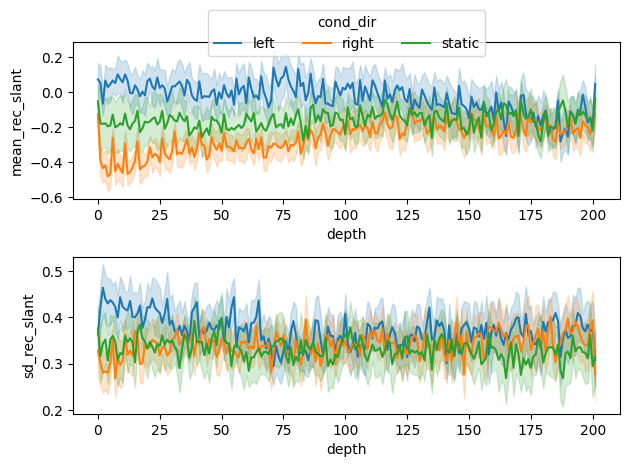

In [131]:
fig, axs = plt.subplots(2)

sns.lineplot(data=df[(df["puppet_state"] == "drifting")], y="mean_rec_slant", x="depth", hue="cond_dir", ax=axs[0])

sns.lineplot(data=df[(df["puppet_state"] == "drifting")], y="sd_rec_slant", x="depth", hue="cond_dir", ax=axs[1], legend=False)
sns.move_legend(axs[0], "upper center", bbox_to_anchor=(0.5, 1.25),ncol=4)

plt.tight_layout()
plt.show()

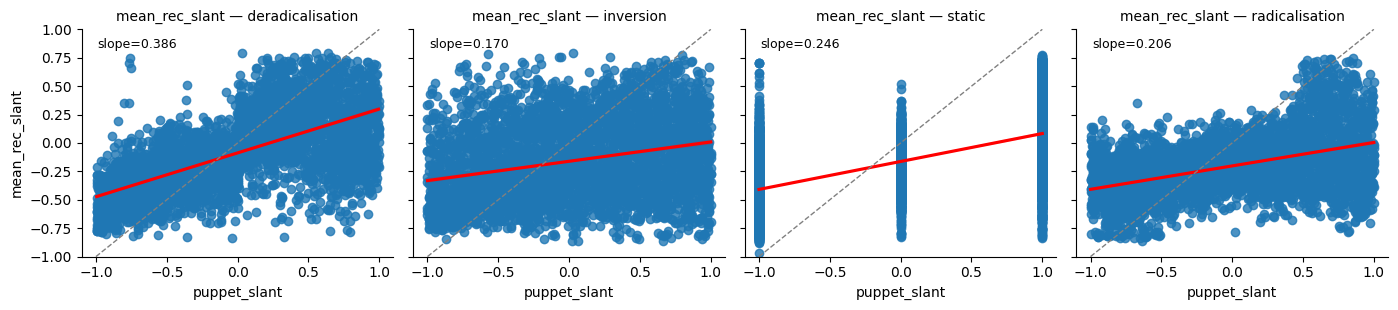

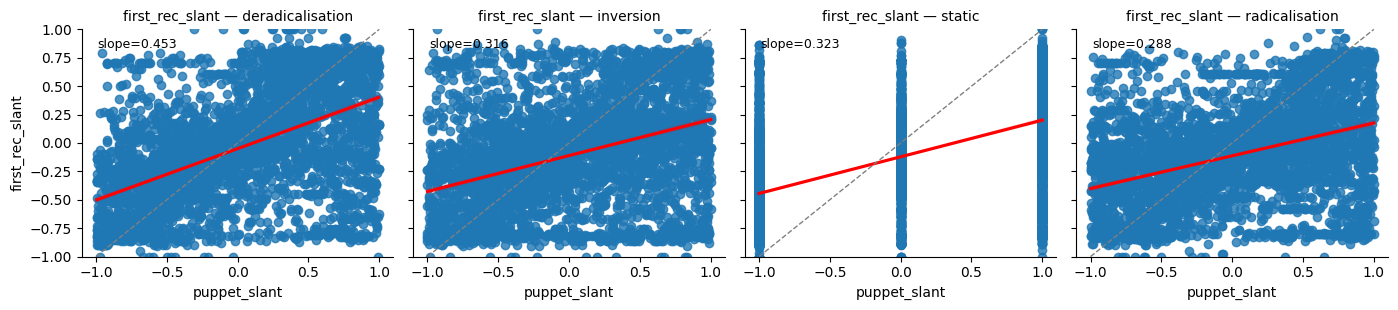

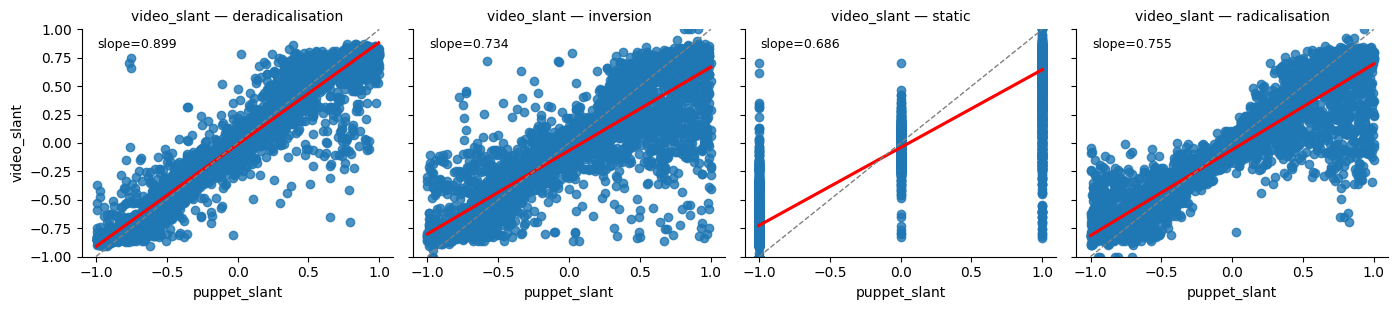

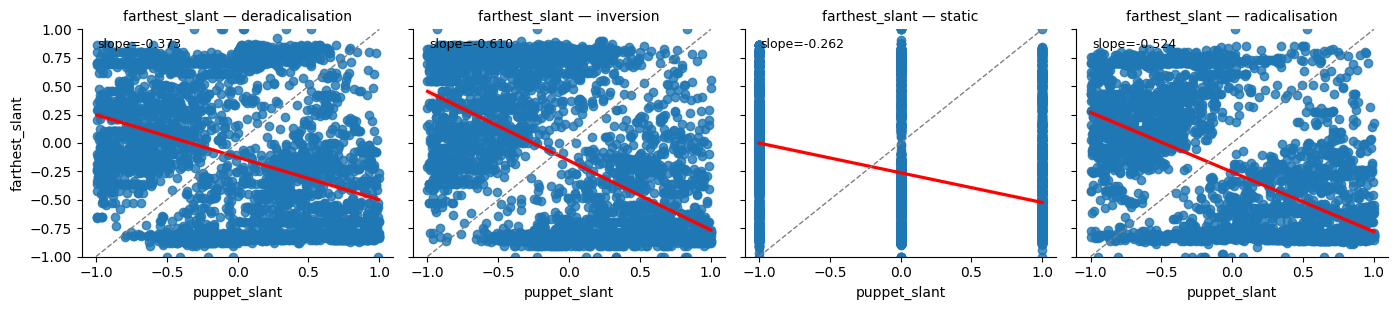

In [ ]:

def congeniality_lmplot(y, x="puppet_slant", df = df, col="cond_group"):
    data = df[
        (df["puppet_state"] == "drifting") &
        (df["source"] == "video")
    ]

    g = sns.lmplot(
        data=data,
        x=x, y=y,
        col=col,
        line_kws=dict(color="r"),
        height=3.2, aspect=1.1
    )

    def _decorate(data, color, **kws):
        ax = plt.gca()
        ax.plot([-1, 1], [-1, 1], "--", linewidth=1, color="gray")
        ax.set_ylim(-1, 1)
        ax.set_xlim(-1.1, 1.1)

        sub = data[[x, y]].replace([np.inf, -np.inf], np.nan).dropna()
        if len(sub) > 1 and sub[x].nunique() > 1:
            res = linregress(sub[x], sub[y])
            ax.text(0.05, 0.92, f"slope={res.slope:.3f}", transform=ax.transAxes, fontsize=9)

    g.map_dataframe(_decorate)
    g.set_titles(col_template=f"{y} — {{col_name}}")
    return g

g1 = congeniality_lmplot(y="mean_rec_slant")
g2 = congeniality_lmplot(y="first_rec_slant")
g3 = congeniality_lmplot(y="video_slant")
g4 = congeniality_lmplot(y="farthest_slant")
plt.show()


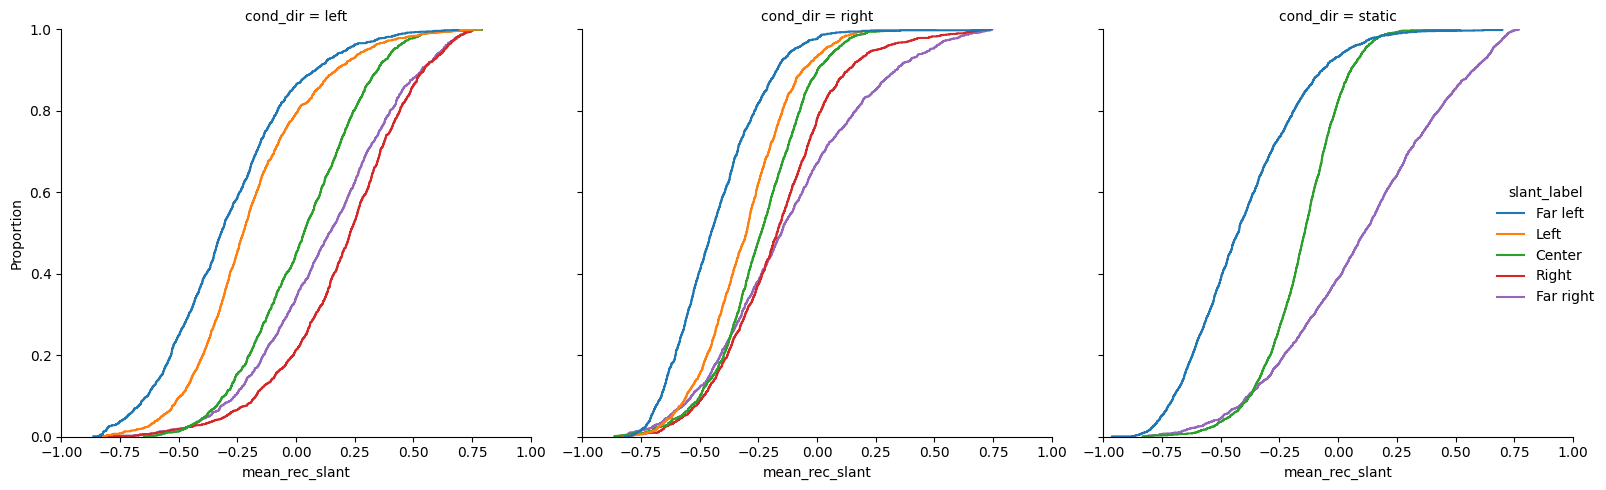

In [167]:
ax = sns.displot(df[df["puppet_state"] == "drifting"], x="mean_rec_slant", hue="slant_label", col="cond_dir", kind="ecdf")
ax.set(xlim=(-1,1))
plt.tight_layout()
plt.show()

In [407]:
mask = ([df["puppet_state"] == "drifting"])
px.histogram(
    df[df["puppet_state"] == "drifting"],
    x="depth",
    color="video_slant_label",
    barnorm="percent",
    barmode="stack",
    facet_col="puppet_cond",
    facet_col_wrap=3,
    category_orders={"video_slant_label": ["Far left", "Left", "Center", "Right", "Far Right"]},
    color_discrete_map={"Far left": "blue", "Left": "lightblue", "Center": "green", "Right": "indianred", "Far right": "red"}
)

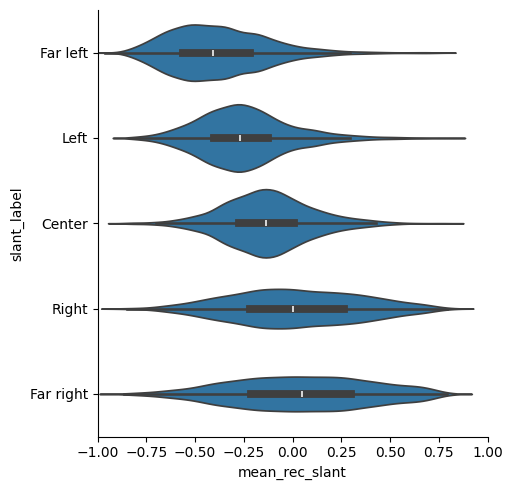

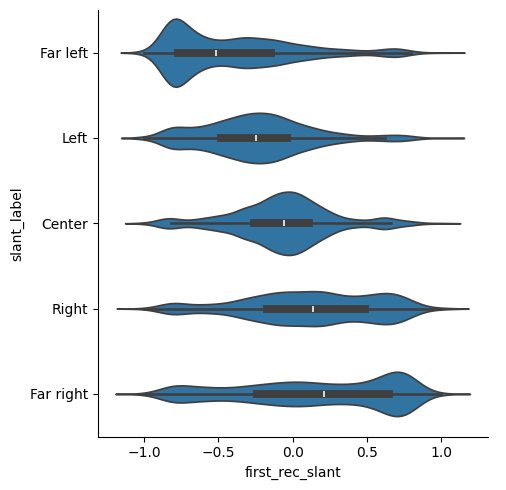

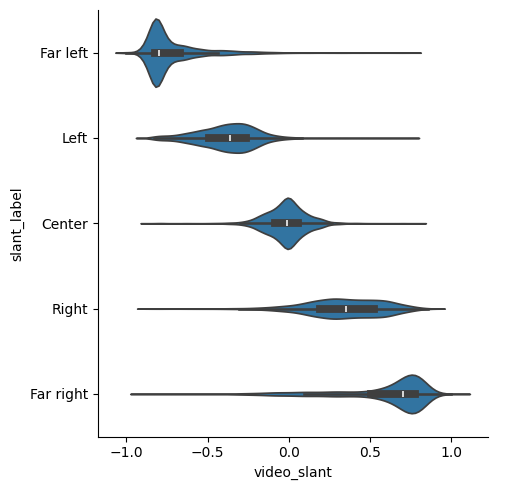

In [148]:
ax = sns.catplot(df[df["puppet_state"] == "drifting"], x="mean_rec_slant", y="slant_label", kind="violin")
ax.set(xlim=(-1,1))
ax1 = sns.catplot(df[df["puppet_state"] == "drifting"], x="first_rec_slant", y="slant_label", kind="violin")
ax2 = sns.catplot(df[df["puppet_state"] == "drifting"], x="video_slant", y="slant_label", kind="violin")

/var/folders/p6/8cdyrdjx0bb9nc27_9f01gpw0000gn/T/ipykernel_7007/343902471.py:3: UserWarning:

Boolean Series key will be reindexed to match DataFrame index.



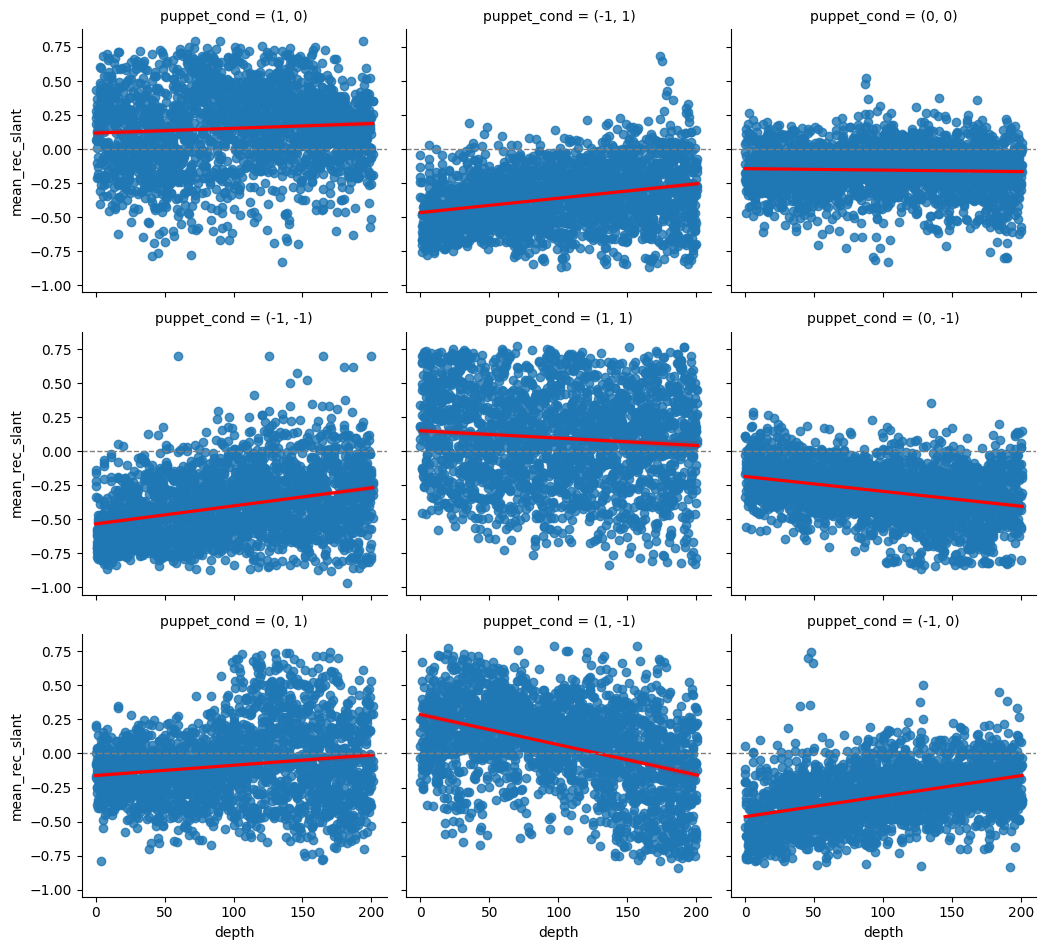

In [390]:
mask = ((df_long["puppet_state"] == "drifting"))    
g = sns.lmplot(
    data=df[mask],
    x="depth", y="mean_rec_slant",
    col="puppet_cond",
    line_kws=dict(color="r"),
    height=3.2, aspect=1.1,
    col_wrap=3
)
for ax in g.axes.flat:
    ax.axhline(0, color="gray", linestyle="--", linewidth=1)

/var/folders/p6/8cdyrdjx0bb9nc27_9f01gpw0000gn/T/ipykernel_7007/3670055125.py:3: UserWarning:

Boolean Series key will be reindexed to match DataFrame index.



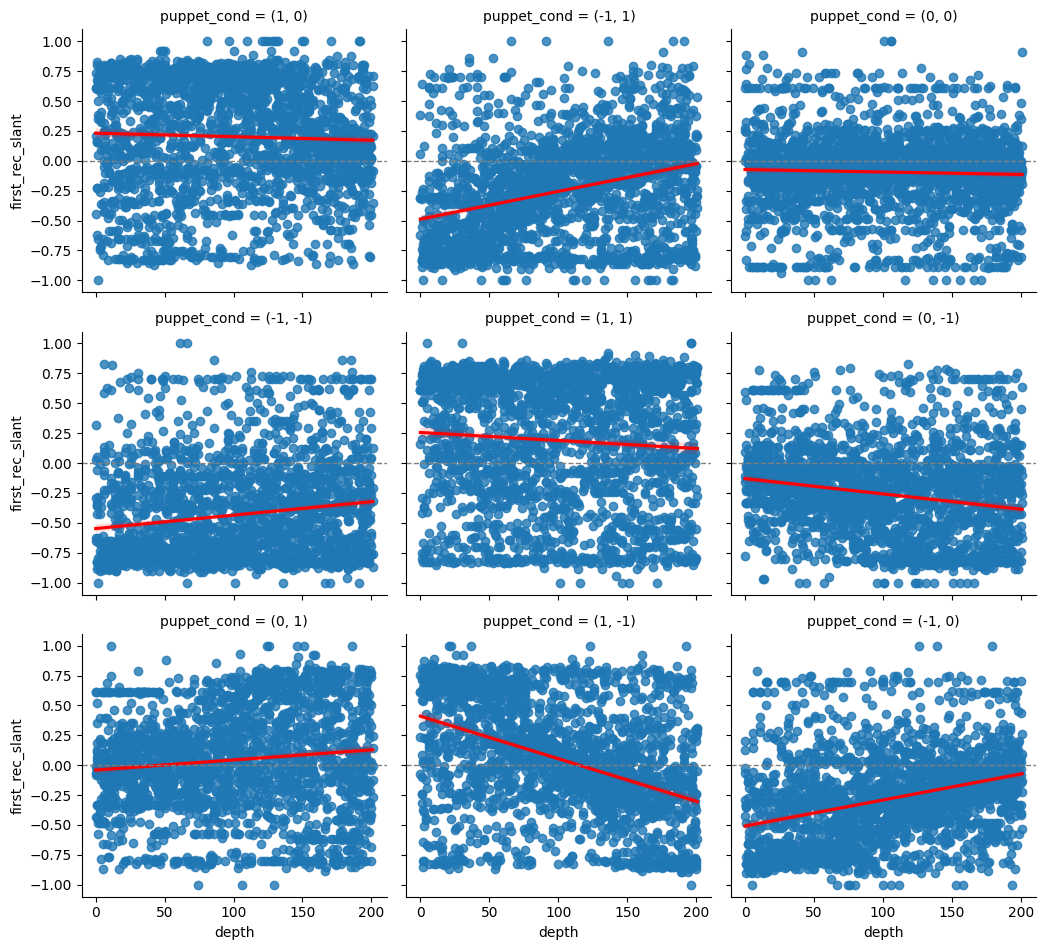

In [391]:
mask = ((df_long["puppet_state"] == "drifting"))    
g = sns.lmplot(
    data=df[mask],
    x="depth", y="first_rec_slant",
    col="puppet_cond",
    line_kws=dict(color="r"),
    height=3.2, aspect=1.1,
    col_wrap=3
)
for ax in g.axes.flat:
    ax.axhline(0, color="gray", linestyle="--", linewidth=1)

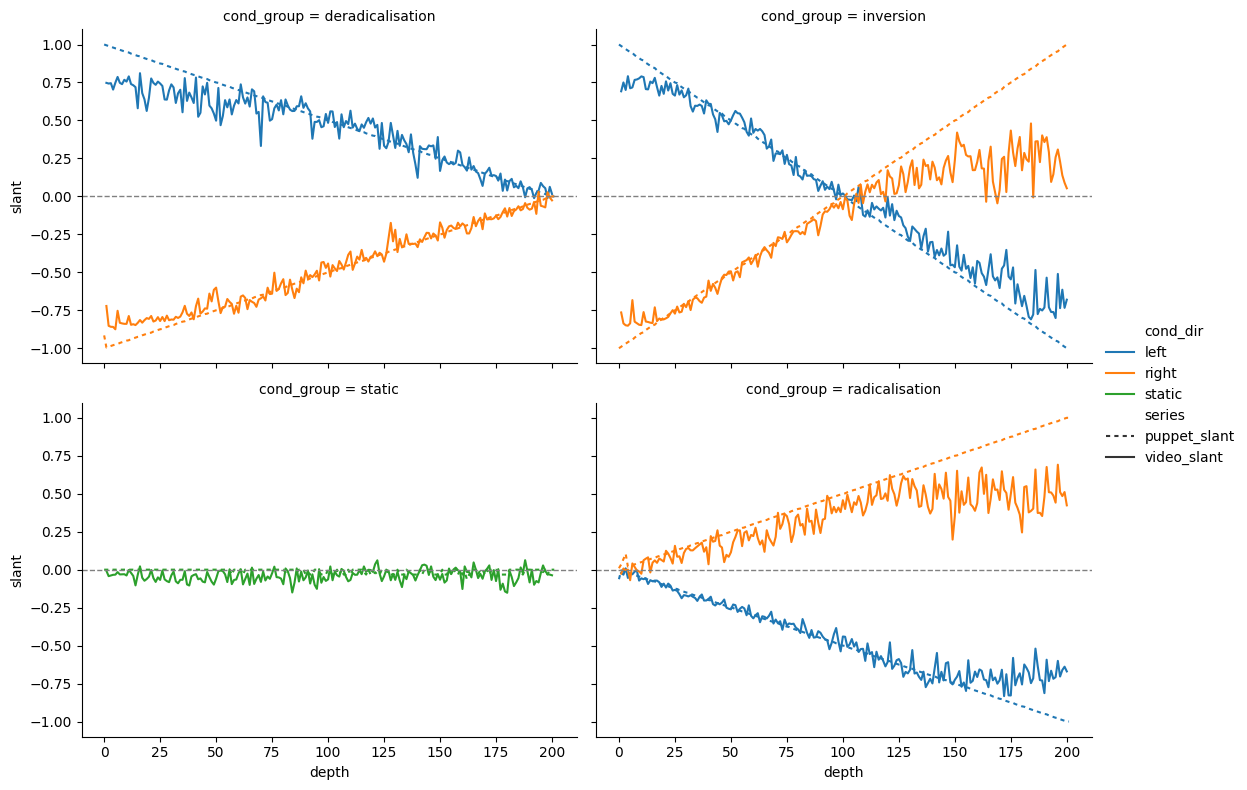

In [384]:
mask = ((df_long["puppet_state"] == "drifting"))
lines_df = df_long[mask & ~df_long["series"].isin(
    ["rec_min", "rec_max", "mean_rec_slant"]
)]


dashes = {
    "puppet_slant":  (2, 2),
    "video_slant": ""
}

fig = sns.relplot(
    data=lines_df,
    dashes=dashes,
    x="depth", y="slant",
    hue="cond_dir",
    col="cond_group",
    style="series",
    kind="line",
    errorbar=None,
    col_wrap=2,
    height=4, aspect=1.4,
)

for ax in fig.axes.flat:
    ax.axhline(0, color="gray", linestyle="--", linewidth=1)




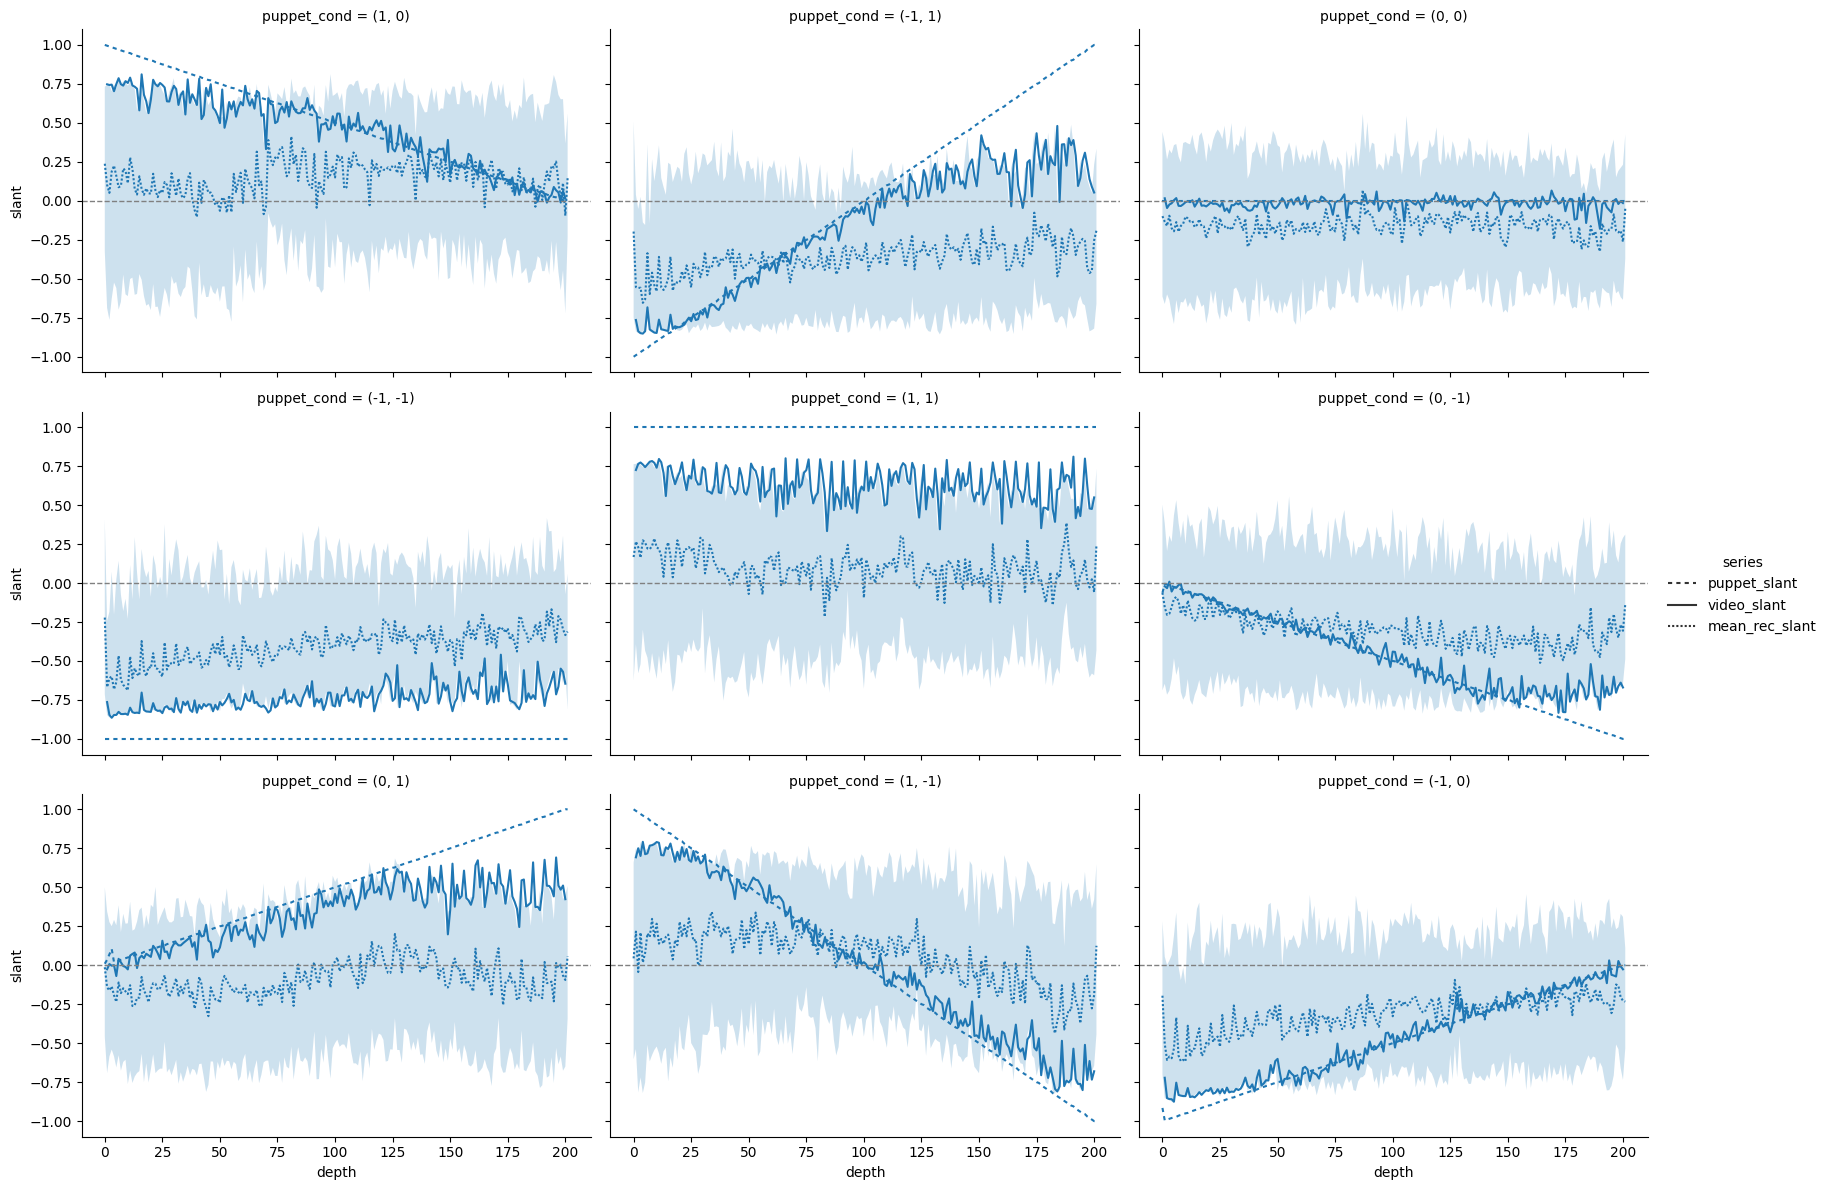

In [387]:
# 1) Plot ONLY the line series you want (exclude rec_min/max as lines)
mask = (df_long["puppet_state"] == "drifting")
lines_df = df_long[mask & ~df_long["series"].isin(
    ["rec_min", "rec_max", "Min rec slant", "Max rec slant"]
)]


dashes = {
    "puppet_slant":  (2, 2),
    "video_slant": "",
    "mean_rec_slant": (1,1)
}

fig = sns.relplot(
    data=lines_df,
    dashes=dashes,
    x="depth", y="slant",
    col="puppet_cond",
    style="series",
    kind="line",
    errorbar=None,
    col_wrap=3,
    height=4, aspect=1.4,
)

for ax in fig.axes.flat:
    ax.axhline(0, color="gray", linestyle="--", linewidth=1)

# 2) Build the band data from the WIDE df (same puppet_state filter)
wide_mask = (df["puppet_state"] == "drifting")
bands = (
    df[wide_mask][["puppet_cond", "depth", "rec_min", "rec_max"]]
    .copy()
)

# OPTIONAL: if you have multiple rows per depth & puppet_cond, aggregate first.
# Choose the summary you want; mean is typical for a smooth band:
bands = (bands
         .groupby(["puppet_cond", "depth"], as_index=False)
         .agg(rec_min=("rec_min", "mean"), rec_max=("rec_max", "mean")))

# 3) Shade per facet, matching each axis with its col value
for cond_val, ax in zip(fig.col_names, fig.axes.flat):
    sub = bands[bands["puppet_cond"] == cond_val].dropna(subset=["rec_min", "rec_max"]).copy()
    if sub.empty:
        continue
    # Ensure numeric and sorted by x
    sub["depth"]   = pd.to_numeric(sub["depth"], errors="coerce")
    sub["rec_min"] = pd.to_numeric(sub["rec_min"], errors="coerce")
    sub["rec_max"] = pd.to_numeric(sub["rec_max"], errors="coerce")
    sub = sub.dropna().sort_values("depth")

    ax.fill_between(
        sub["depth"].to_numpy(),
        sub["rec_min"].to_numpy(),
        sub["rec_max"].to_numpy(),
        alpha=0.22, linewidth=0, label="Rec range"
    )

    # Keep a single legend entry
    handles, labels = ax.get_legend_handles_labels()
    if "Rec range" not in labels:
        ax.legend(loc="best")

plt.show()



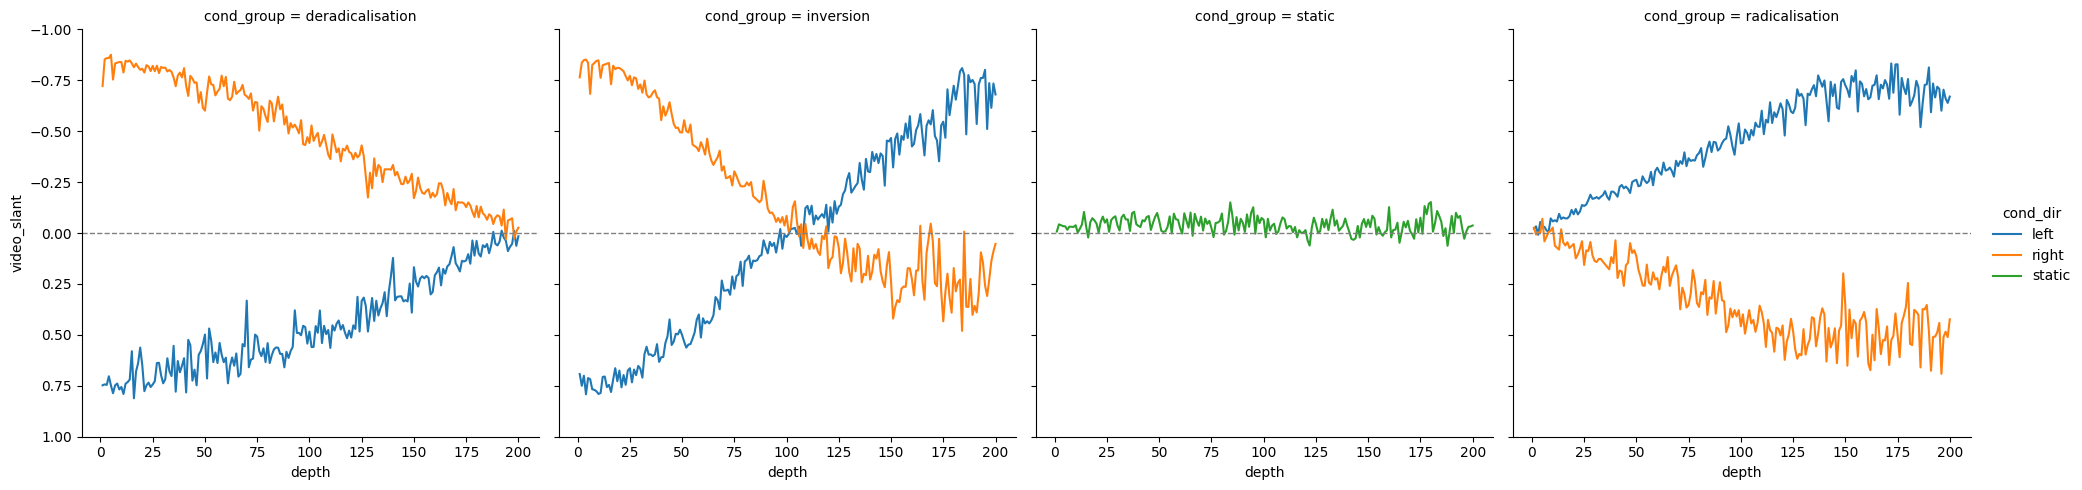

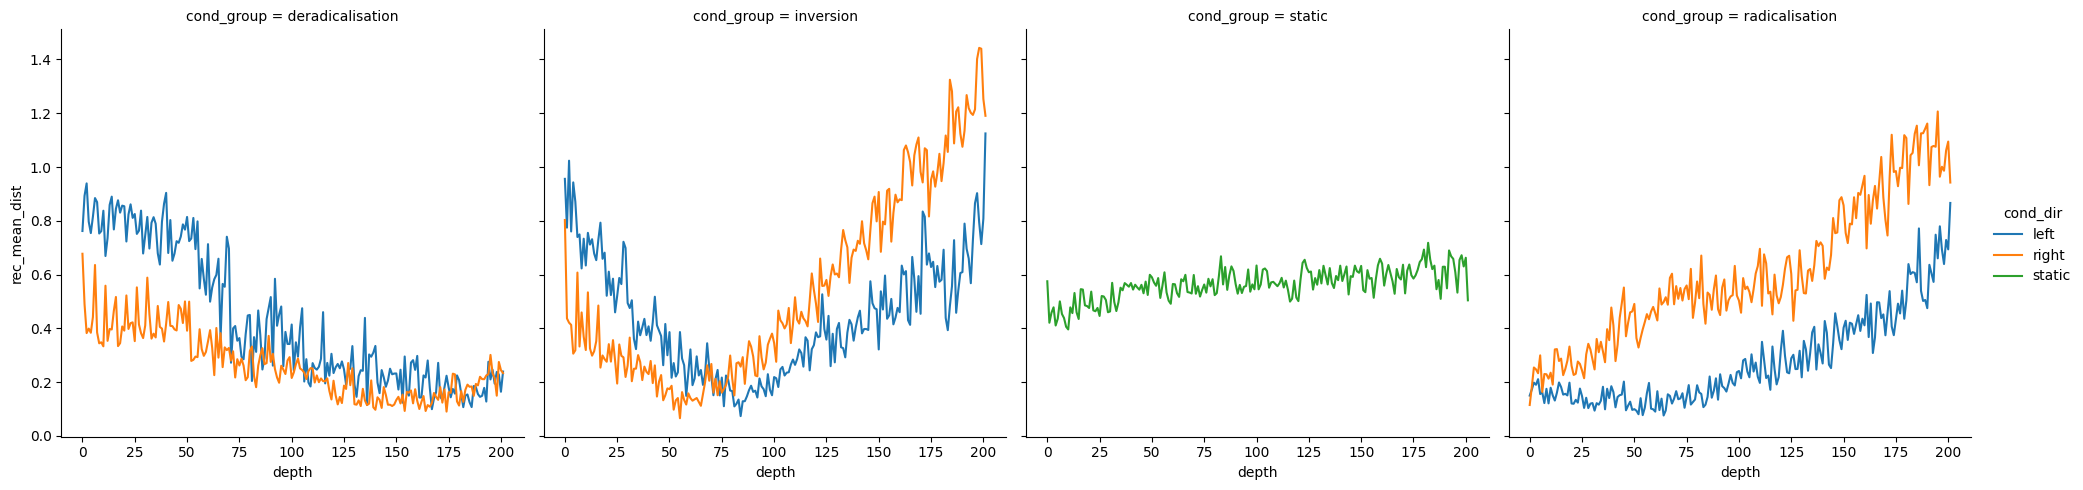

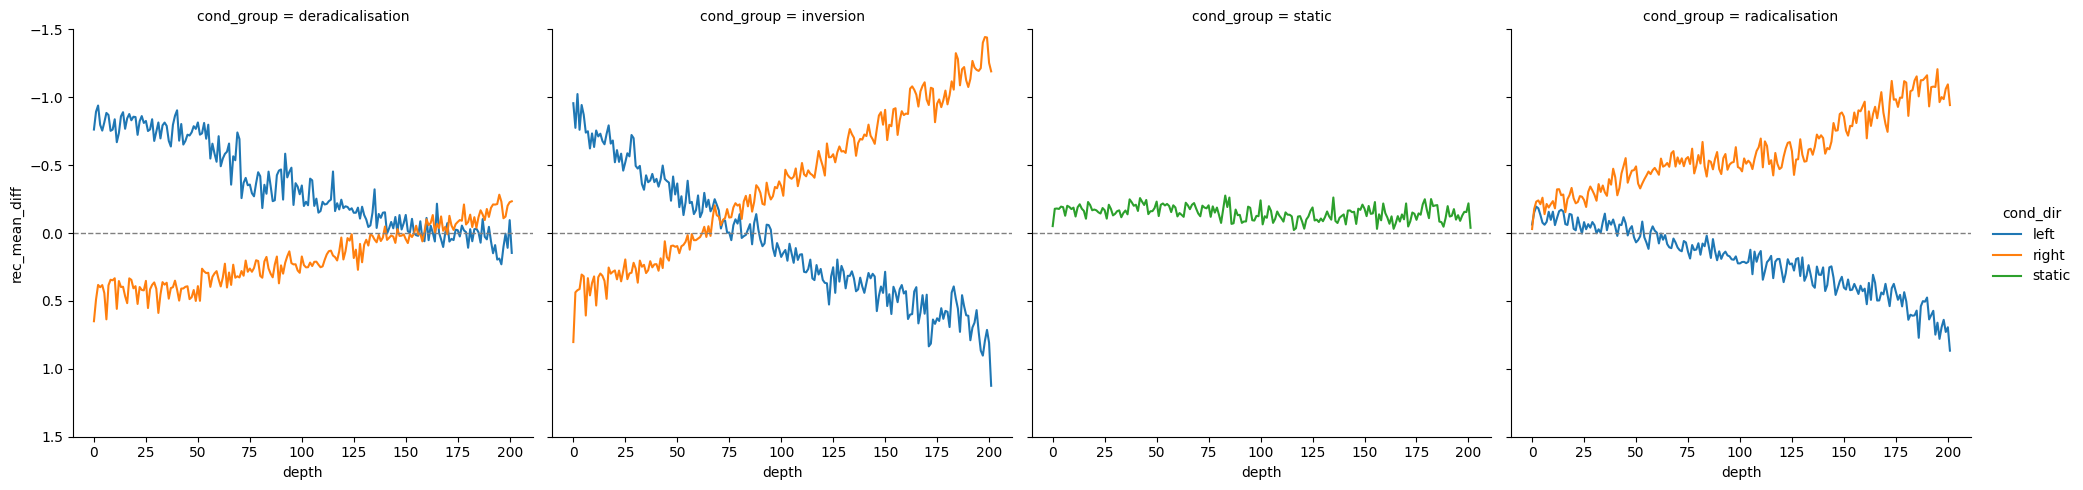

In [ ]:
mask = ((df["puppet_state"] == "drifting"))
fig2=sns.relplot(df[mask],x="depth", y="rec_mean_dist", hue = "cond_dir", col="cond_group", kind="line", errorbar=None)
fig3= sns.relplot(df[mask],x="depth", y="rec_mean_diff", hue = "cond_dir", col="cond_group", kind="line", errorbar=None)
fig3.set(ylim=(1.5,-1.5))
for ax in fig3.axes.flat:
    ax.axhline(0, color="gray", linestyle="--", linewidth=1)


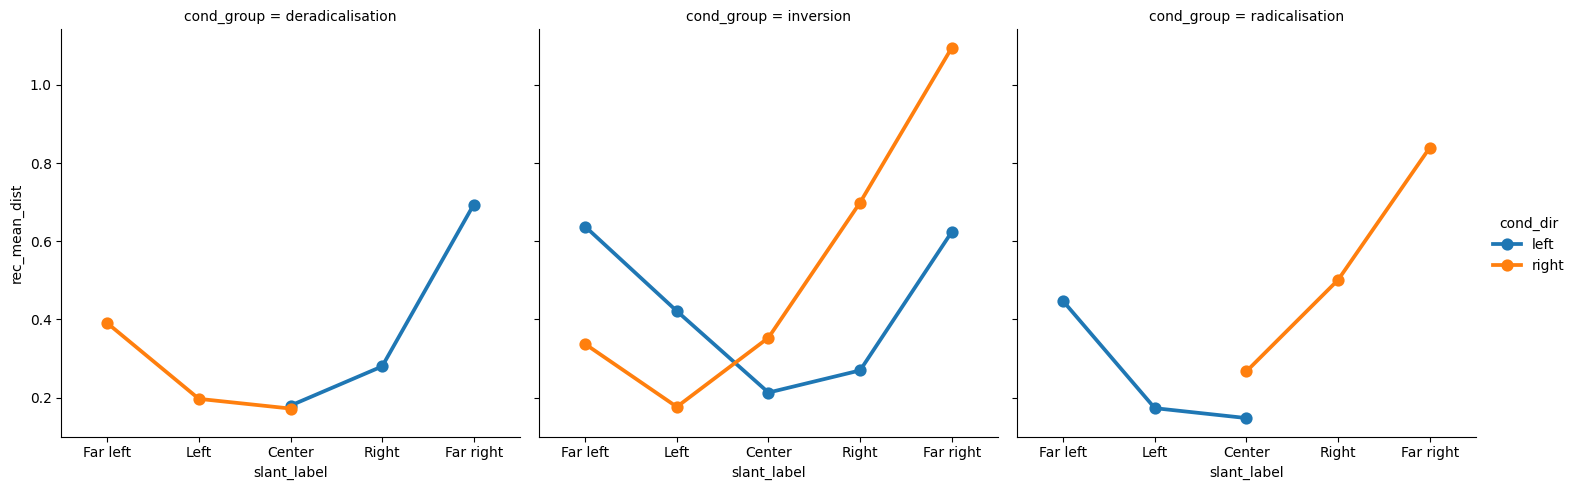

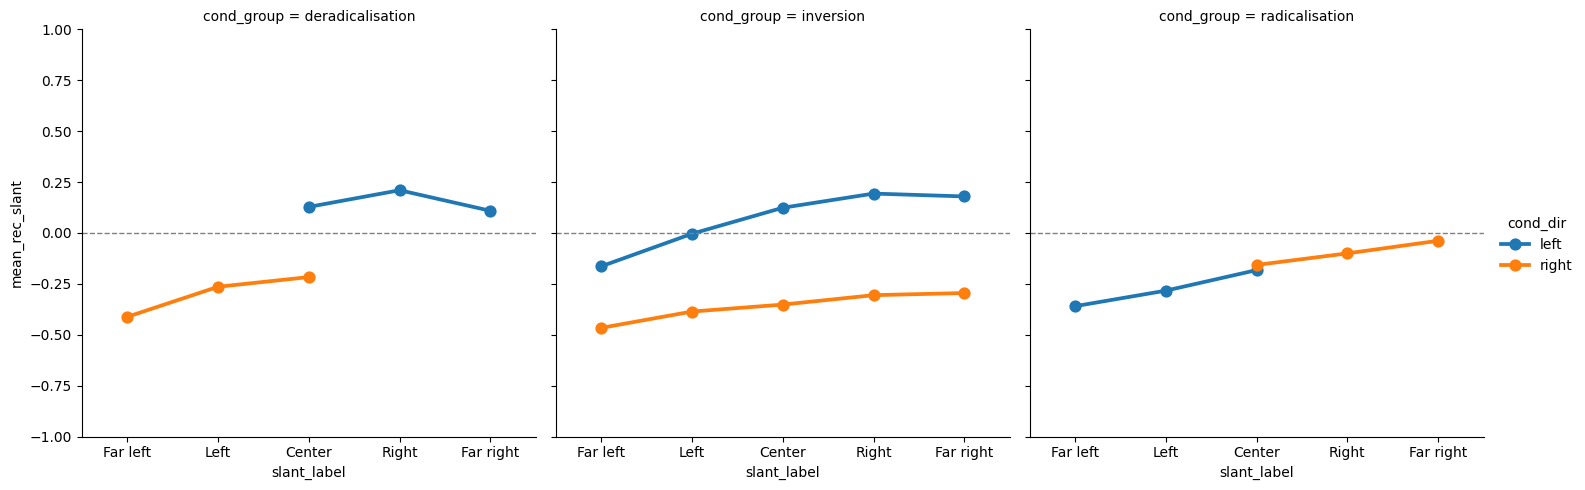

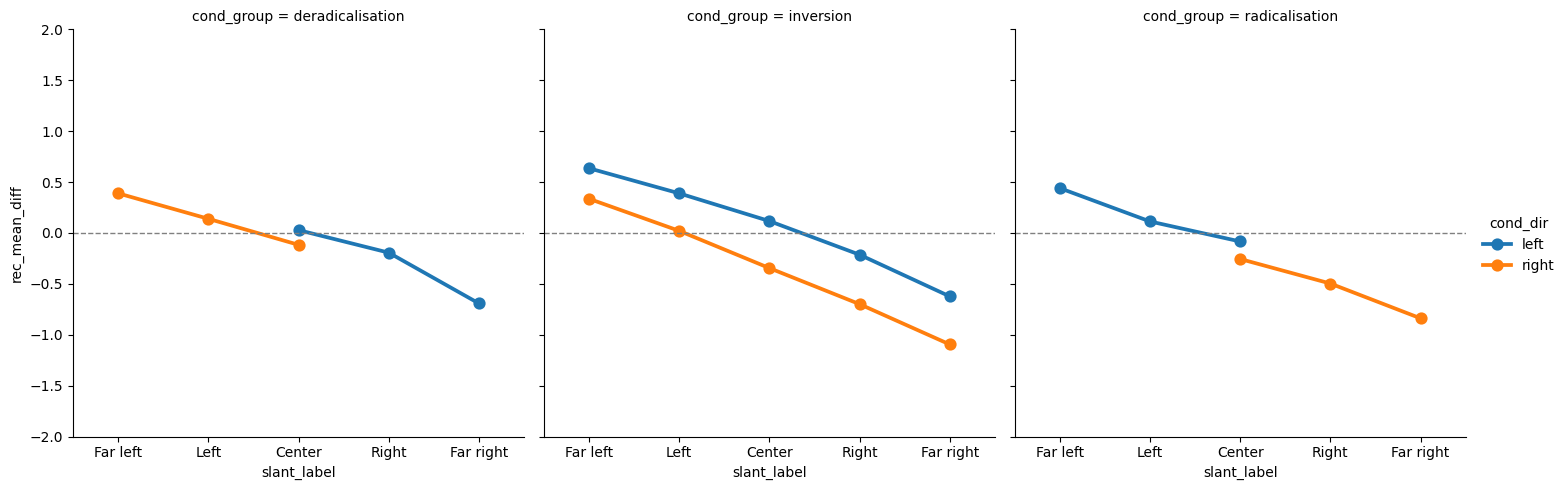

In [284]:
mask = ((df["puppet_state"] == "drifting") & (df["cond_group"] != "static"))

g0 = sns.catplot(
    data=df[mask],
    x="slant_label", y="rec_mean_dist",
    hue="cond_dir", col="cond_group",
    kind="point", estimator="mean",
    errorbar=None
)

g1 = sns.catplot(
    data=df[mask],
    x="slant_label", y="mean_rec_slant",
    hue="cond_dir", col="cond_group",
    kind="point", estimator="mean",
    errorbar=None
)

g2 = sns.catplot(
    data=df[mask],
    x="slant_label", y="rec_mean_diff",
    hue="cond_dir", col="cond_group",
    kind="point", estimator="mean",
    errorbar=None
)

for ax in g1.axes.flat:
    ax.axhline(0, color="gray", linestyle="--", linewidth=1)
    ax.set(ylim=(-1,1))

for ax in g2.axes.flat:
    ax.axhline(0, color="gray", linestyle="--", linewidth=1)
    ax.set(ylim=(-2,2))

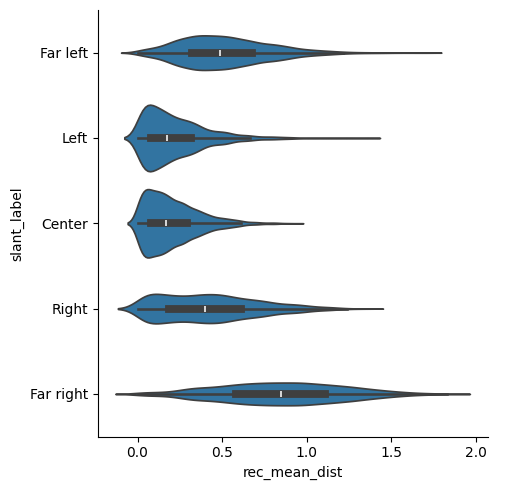

In [145]:
mask = ((df["puppet_state"] == "drifting"))
sns.catplot(df[mask], y="slant_label",x="rec_mean_dist", kind="violin")

/Users/gustavidunsloth/Documents/Data Science/YouTube Algorithm Audit/.venv/lib/python3.11/site-packages/joypy/joyplot.py:176: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data.groupby(by)


(<Figure size 640x480 with 6 Axes>,
 [<Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: title={'center': 'Far-left to far-right drift'}>])

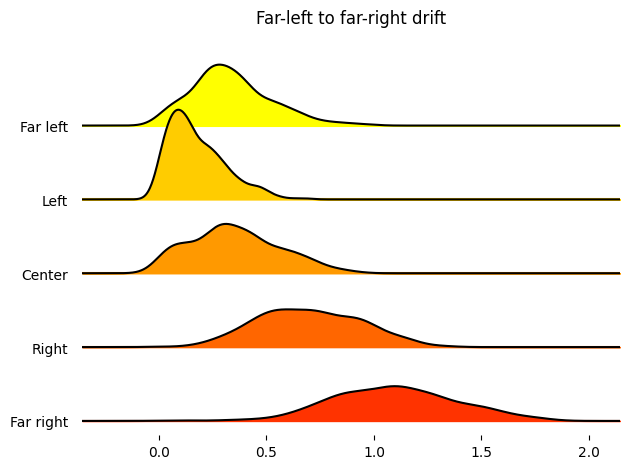

In [140]:
from joypy import joyplot
from matplotlib.pyplot import cm

mask = ((df["puppet_state"] == "drifting") & (df["puppet_cond"] == (-1,1)))
joyplot(df[mask], column="rec_mean_dist", by="slant_label", overlap=0.5, colormap=cm.autumn_r, title="Far-left to far-right drift")

In [ ]:
from data_fetcher import get_videos_by_id

#fetch metadata from db
mask = (df["puppet_state"] == "drifting")

def get_videos(id):
    vid = get_videos_by_id([id])
    if len(vid) > 0:
        return vid[0]
    else:
        return None

#populate the df
df_metadata = df[mask]
df_metadata["vid_obj"] = df["video_id"].apply(lambda id: get_videos(id))

df_metadata["channel"] = df_metadata["vid_obj"].apply(lambda vid: None if vid == None else vid.channel)
df_metadata["video_title"] = df_metadata["vid_obj"].apply(lambda vid: None if vid == None else vid.title)

df_metadata


2025-10-18 14:49:31 [INFO] Database: Fetched 1/1 videos...
2025-10-18 14:49:31 [INFO] Database: Fetched 1/1 videos...
2025-10-18 14:49:31 [INFO] Database: Fetched 1/1 videos...
2025-10-18 14:49:31 [INFO] Database: Fetched 1/1 videos...
2025-10-18 14:49:31 [INFO] Database: Fetched 1/1 videos...
2025-10-18 14:49:31 [INFO] Database: Fetched 1/1 videos...
2025-10-18 14:49:31 [INFO] Database: Fetched 1/1 videos...
2025-10-18 14:49:31 [INFO] Database: Fetched 1/1 videos...
2025-10-18 14:49:31 [INFO] Database: Fetched 1/1 videos...
2025-10-18 14:49:31 [INFO] Database: Fetched 1/1 videos...
2025-10-18 14:49:31 [INFO] Database: Fetched 1/1 videos...
2025-10-18 14:49:31 [INFO] Database: Fetched 1/1 videos...
2025-10-18 14:49:31 [INFO] Database: Fetched 1/1 videos...
2025-10-18 14:49:31 [INFO] Database: Fetched 1/1 videos...
2025-10-18 14:49:31 [INFO] Database: Fetched 1/1 videos...
2025-10-18 14:49:31 [INFO] Database: Fetched 1/1 videos...
2025-10-18 14:49:31 [INFO] Database: Fetched 1/1 videos.

,puppet_id,puppet_state,puppet_slant,puppet_cond,depth,video_id,video_slant,recs_id,recs_slant,errors,...,slant_label,cond_group,cond_dir,static,rec_mean_dist,farthest_slant,rec_mean_diff,video_slant_label,vid_obj,channel
100,p-5r6HPyFwYJbGTuhGWtKwYL,drifting,1.000000e+00,"(1, 0)",0,None,NaN,"[YHf7ka_ZDv4, WtfL63Jdzrg, gsZtIN3JtGI, bgnWcT...","[-0.4489034414291382, -0.03817880153656006, 0....",[],...,Far right,deradicalisation,left,False,0.929956,-0.448903,-0.929956,NaN,None,None
101,p-5r6HPyFwYJbGTuhGWtKwYL,drifting,9.950000e-01,"(1, 0)",1,bgnWcTIr050,0.656666,"[2O1C9KGS-Xs, Ztn6o0dmFI0, d8RBM0yV_zc, v1Gm1O...","[-0.22566485404968262, -0.35659706592559814, -...",[],...,Far right,deradicalisation,left,False,1.205244,-0.818910,-1.205244,Far right,"Video ID: bgnWcTIr050, video slant: None",Turning Point USA
102,p-5r6HPyFwYJbGTuhGWtKwYL,drifting,9.900000e-01,"(1, 0)",2,v1Gm1OR2SPg,0.699848,"[pDJZ6n08Suk, X61vAlTJSGY, SeyOlaHz0aU, giLrq1...","[0.498507022857666, -0.7909277081489563, -0.79...",[],...,Far right,deradicalisation,left,False,1.170187,-0.829144,-1.170187,Far right,"Video ID: v1Gm1OR2SPg, video slant: None",Hoover Institution
103,p-5r6HPyFwYJbGTuhGWtKwYL,drifting,9.850000e-01,"(1, 0)",3,giLrq1ufU4M,0.766193,"[u4ltwrmC8e0, ca6K0eokYk0, k8KIv5FSol0, 8RqNxt...","[0.7505935430526733, 0.5127637386322021, 0.544...",[PlaybackException],...,Far right,deradicalisation,left,False,0.551531,-0.829144,-0.551531,Far right,"Video ID: giLrq1ufU4M, video slant: None",FOX 5 New York
104,p-5r6HPyFwYJbGTuhGWtKwYL,drifting,9.800000e-01,"(1, 0)",4,fT0UjjjAvdc,0.780694,"[b4jTc1YpEgM, SeyOlaHz0aU, mo_ZhGIE8xQ, xxw0If...","[-0.3599674105644226, -0.7939653992652893, -0....",[PlaybackException],...,Far right,deradicalisation,left,False,1.240542,-0.829144,-1.240542,Far right,"Video ID: fT0UjjjAvdc, video slant: None",Fox News
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30535,p-Fdz9MD2hiZSajxwNabAaKZ,drifting,-1.500000e-02,"(-1, 0)",197,jhogoq-cYdI,0.054698,"[DgpcSZWiPX8, FoNzn5Ylghw, q3FuvWXoDZA, F_ety6...","[-0.020939290523529053, -0.10082352161407471, ...",[],...,Center,deradicalisation,right,False,0.204265,-0.743858,-0.204265,Center,"Video ID: jhogoq-cYdI, video slant: None",Liam Dempsey
30536,p-Fdz9MD2hiZSajxwNabAaKZ,drifting,-1.000000e-02,"(-1, 0)",198,DgpcSZWiPX8,-0.020939,"[vQAJ1sYCqSk, FoNzn5Ylghw, qEqk7DroAsc, ZBeCWy...","[0.45587313175201416, -0.10082352161407471, 0....",[],...,Center,deradicalisation,right,False,0.171832,-0.799252,-0.171832,Center,"Video ID: DgpcSZWiPX8, video slant: None",Mordian Glory
30537,p-Fdz9MD2hiZSajxwNabAaKZ,drifting,-5.000000e-03,"(-1, 0)",199,F_ety6L2Zzo,0.028148,"[DzEzLcNs4yI, c19-9QXHf60, ec33NiMsOmg, 3B733p...","[-0.3579520583152771, 0.029949665069580078, -0...",[],...,Center,deradicalisation,right,False,0.369966,-0.848826,-0.369966,Center,"Video ID: F_ety6L2Zzo, video slant: None",The Bitchuation Room (with Francesca Fiorentini)
30538,p-Fdz9MD2hiZSajxwNabAaKZ,drifting,8.205242e-16,"(-1, 0)",200,3B733pFAIbQ,-0.027691,"[T7uWPBmcPyY, MaPkMmABRi8, DzEzLcNs4yI, KjHR87...","[0.7071268558502197, -0.7988132238388062, -0.3...",[],...,Center,deradicalisation,right,False,0.263996,-0.798813,-0.263996,Center,"Video ID: 3B733pFAIbQ, video slant: None",Mr Sandsman


In [165]:
# top most watched channels
ch_count = df_metadata["channel"].value_counts()
ch_count[:20]

channel
Forbes Breaking News                  612
MSNBC                                 599
Democracy Now!                        523
Sky News Australia                    431
The Late Show with Stephen Colbert    427
Fox News                              281
The White House                       209
PBS NewsHour                          187
Heather Cox Richardson                159
BBC World Service                     155
Bloomberg Podcasts                    153
LastWeekTonight                       147
Glenn Kirschner                       125
Brian Tyler Cohen                     122
Jimmy Kimmel Live                     117
Amanpour and Company                  116
Hoover Institution                    106
Fox Business                          105
CNBC Television                       105
The Daily Show                         99
Name: count, dtype: int64

In [193]:
#compute channel slant from mean of videos
ch_grouped = df_metadata.groupby("channel").agg(views=("channel", "count"), channel_slant=("video_slant", "mean")).reset_index()
ch_grouped

,channel,views,channel_slant
0,VINHCAO-CÔ DÂU VIỆT Ở MALAYSIA,1,0.045390
1,Dr. Joy Ariyo.,1,-0.341614
2,FanTaisia Ambience,1,0.031446
3,Piano inspiré,2,-0.015236
4,Reign With Josh Smith,1,-0.338645
...,...,...,...
5278,효명아트홀(HM Art Hall),1,0.769423
5279,휘인 offwheecial,1,0.144485
5280,ｴﾝﾄﾞﾐｰ-ﾙｼｸﾞﾚ㌠,1,0.696737
5281,𝐃𝐚𝐫𝐤 𝐀𝐜𝐚𝐝𝐞𝐦𝐢𝐚 𝐌𝐞𝐦𝐨𝐢𝐫𝐬,5,-0.015945


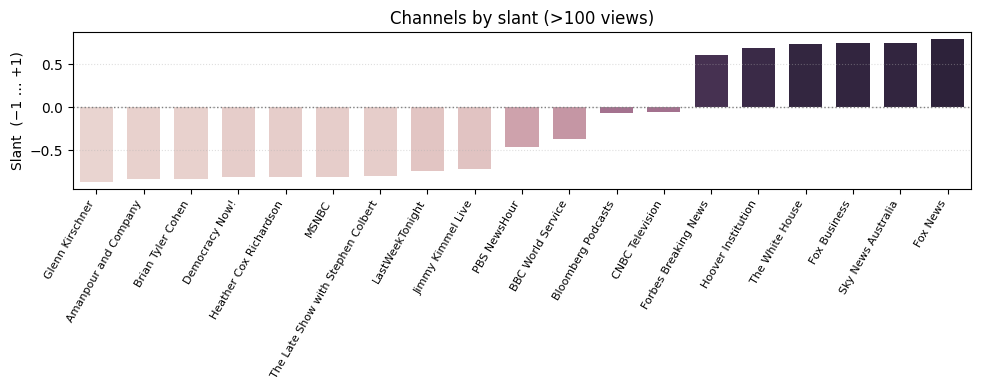

In [252]:
# Filter and sort
df_plot = ch_grouped.loc[ch_grouped["views"] > 100].copy()
df_plot = df_plot.sort_values("channel_slant").reset_index(drop=True)

plt.figure(figsize=(10, 4))  # shorter height

sns.barplot(
    data=df_plot,
    x="channel",
    y="channel_slant",
    orient="v",
    hue="channel_slant",
    legend=False,
    width=0.7,  # thinner bars
)

# Rotate channel names
plt.xticks(rotation=60, ha="right", fontsize=8)

# Cosmetic touches
plt.axhline(0, color="gray", linestyle=":", linewidth=1)
plt.ylabel("Slant  (−1 … +1)")
plt.xlabel("")
plt.title("Channels by slant (>100 views)")
plt.grid(axis="y", linestyle=":", alpha=0.4)
plt.tight_layout()
plt.show()


In [ ]:
px.histogram(ch_grouped, x = "channel_slant", title="Slant count of watched videos")

In [289]:
vid_grouped = df_metadata.groupby("video_title").agg(views=("video_title", "count"), video_slant=("video_slant", "mean")).reset_index()
vid_grouped

vid_grouped["video_slant_label"] = pd.cut(
    vid_grouped["video_slant"],
    bins=[-1.1, -0.6, -0.2, 0.2, 0.6, 1.1],
    labels=["Far left", "Left", "Center", "Right", "Far right"]
)

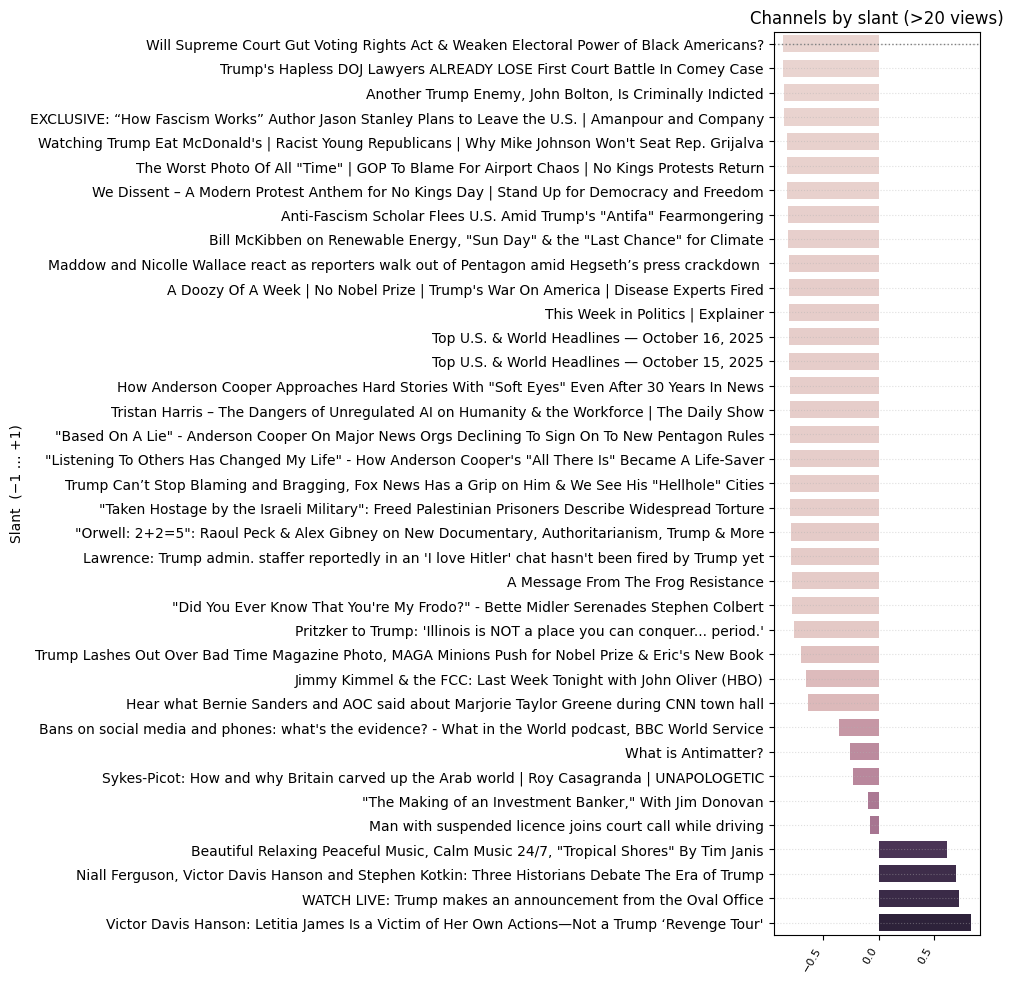

In [ ]:
# Filter and sort
df_plot = vid_grouped.loc[vid_grouped["views"] > 20].copy()
df_plot = df_plot.sort_values("video_slant").reset_index(drop=True)

plt.figure(figsize=(10, 10))  # shorter height

sns.barplot(
    data=df_plot,
    y="video_title",
    x="video_slant",
    hue="video_slant",
    orient="h",
    width=0.7,  # thinner bars
    legend=False
)

# Rotate channel names
plt.xticks(rotation=60, ha="right", fontsize=8)

# Cosmetic touches
plt.axhline(0, color="gray", linestyle=":", linewidth=1)
plt.ylabel("Slant  (−1 … +1)")
plt.xlabel("")
plt.title("Top videos by slant (>20 views)")
plt.grid(axis="y", linestyle=":", alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
sns.pointplot(vid_grouped, y = "views", x="video_slant_label")

In [246]:
px.histogram(vid_grouped, x = "video_slant")

In [264]:
from bertopic import BERTopic

docs = vid_grouped["video_title"]

topic_model = BERTopic()
topics, probs = topic_model.fit_transform(docs)

/Users/gustavidunsloth/Documents/Data Science/YouTube Algorithm Audit/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/Users/gustavidunsloth/Documents/Data Science/YouTube Algorithm Audit/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



In [270]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,3727,-1_the_and_to_of,"[the, and, to, of, is, in, on, for, live, trump]",[How Pro-Trump Billionaires Are Taking Over U....
1,0,445,0_god_prayer_jesus_bible,"[god, prayer, jesus, bible, message, morning, ...","[GOD SAYS- ""BEFORE IT'S TOO LATE! PLEASE"" God ..."
2,1,310,1_guitar_piano_lesson_orchestra,"[guitar, piano, lesson, orchestra, solo, metal...",[Comfortably Numb | Guitar Cover Tab | Guitar ...
3,2,242,2_de_la_en_el,"[de, la, en, el, que, da, vivo, du, del, por]",[Los violines del Mariachi de América de Jesús...
4,3,162,3_ceo_markets_market_nvidia,"[ceo, markets, market, nvidia, crypto, bloombe...",[Exclusive Interview With Nvidia CEO Jensen Hu...
...,...,...,...,...,...
164,163,10,163_volkel_d5_f35a_a380,"[volkel, d5, f35a, a380, vapor, 4k, flying, go...",[[4K] Volkel; F-35A Kicks in the Afterburner a...
165,164,10,164_fireplace_cozy_ambience_halloween,"[fireplace, cozy, ambience, halloween, rainy, ...",[🎃 24/7 LIVE Autumn Halloween Fireplace Ambien...
166,165,10,165_oil_india_assured_russian,"[oil, india, assured, russian, modi, pm, major...",[News Today With Rajdeep Sardesai: India Denie...
167,166,10,166_spanish_guitar_flamenco_imad,"[spanish, guitar, flamenco, imad, fares, enriq...",[Flamenco Spanish love song| Top Spanish Style...


In [ ]:
fig = topic_model.visualize_topics()          # interactive
fig.show()  

/Users/gustavidunsloth/Documents/Data Science/YouTube Algorithm Audit/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



In [271]:
# After fitting
# topics, probs = topic_model.fit_transform(docs)

doc_info = topic_model.get_document_info(docs)  # has columns: Document, Topic, Probability, ...

# If your slants live in a parallel DataFrame aligned with docs:
# df_videos has a column "video_slant" (and optionally "views")
doc_info["video_slant"] = vid_grouped["video_slant"].to_numpy()
doc_info["views"] = vid_grouped.get("views", 1)

# Drop outliers topic = -1
doc_info = doc_info[doc_info["Topic"] != -1]

# Aggregate per topic (weighted mean by views optional)
import numpy as np, pandas as pd

g = doc_info.groupby("Topic", as_index=False)
topic_stats = g.apply(lambda d: pd.Series({
    "n": len(d),
    "mean_slant": np.average(d["video_slant"], weights=d["views"]),
    "median_slant": np.median(d["video_slant"]),
    "sd_slant": d["video_slant"].std(ddof=1) if len(d) > 1 else 0.0,
    "mean_prob": d["Probability"].mean(),
})).reset_index(drop=True)

# Human-readable names from top words
def topic_name(tid, topn=6):
    words = [w for w,_ in (topic_model.get_topic(tid) or [])][:topn]
    return ", ".join(words)

topic_stats["name"] = topic_stats["Topic"].apply(topic_name)
topic_stats = topic_stats.sort_values("mean_slant").reset_index(drop=True)


/var/folders/p6/8cdyrdjx0bb9nc27_9f01gpw0000gn/T/ipykernel_7007/518391708.py:18: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [272]:
topic_stats

,Topic,n,mean_slant,median_slant,sd_slant,mean_prob,name
0,150,12.0,-0.800689,-0.821337,0.300494,0.973109,"odonnell, word, lawrence, audio, only, last"
1,67,32.0,-0.770774,-0.806727,0.295453,0.847681,"headlines, top, september, world, us, 2025"
2,71,31.0,-0.734049,-0.739847,0.446805,0.830206,"authoritarian, fascism, democracy, authoritari..."
3,153,12.0,-0.728039,-0.663709,0.258935,0.965832,"colbert, stephen, burnett, pac, questionert, c..."
4,100,21.0,-0.728002,-0.800617,0.568294,0.664882,"hegseths, pentagon, hegseth, pete, press, rules"
...,...,...,...,...,...,...,...
163,47,43.0,0.652609,0.717248,0.225266,0.951283,"mass, october, catholic, daily, 2025, friday"
164,7,120.0,0.681735,0.739300,0.314882,0.955825,"charlie, kirk, medal, kirks, freedom, erika"
165,81,26.0,0.731092,0.732640,0.205083,0.961155,"lady, melania, signs, executive, president, pa..."
166,145,13.0,0.761192,0.815800,0.119594,0.908658,"robertson, phil, home, jeanne, at, repentance"


/var/folders/p6/8cdyrdjx0bb9nc27_9f01gpw0000gn/T/ipykernel_7007/4129683421.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




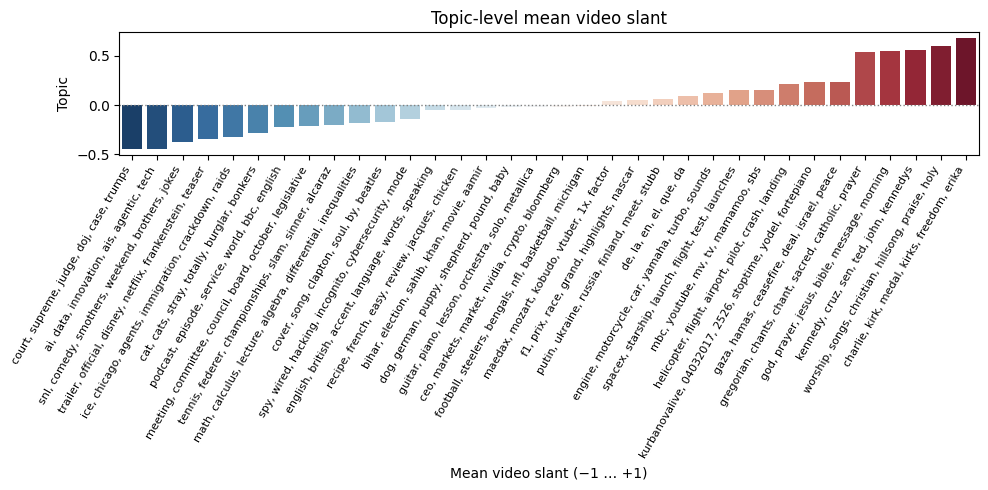

In [288]:
mask=(topic_stats["n"] > 50)
plt.figure(figsize=(10, 5))
sns.barplot(
    data=topic_stats[mask],
    x="name",
    y="mean_slant",
    palette="RdBu_r",
    orient="v",
)
plt.xticks(rotation=60, ha="right", fontsize=8)
plt.axhline(0, color="gray", linestyle=":", linewidth=1)
plt.xlabel("Mean video slant (−1 … +1)")
plt.ylabel("Topic")
plt.title("Topic-level mean video slant")
plt.tight_layout()
plt.show()
